# Trajectory Analysis across models for _Suo et. al._ with Bootstapped Subgraphs

In [1]:
0

0

In [2]:
%load_ext autoreload
%autoreload 2

In [15]:
import sys
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import logging
import subprocess
import gc
import tqdm
import os
import time
import itertools
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad

sc.settings.verbose = 3

In [4]:
from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.input import InputTrajectories
from sctram.generate.real import sc_suo_developmental_complete

2025-03-18 16:51:30.676 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-03-18 16:51:30.761 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [5]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

Download the dataset and preliminary subsetting

In [6]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

In [7]:
adata_suo_complete = sc_suo_developmental_complete(dataset_dir=dataset_dir)
display(adata_suo_complete)

2025-03-18 16:51:34.891 | WARNING  | sctram.generate.real._download:download_dataset:105 - File PosixPath('/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/suo_developmental_complete.h5ad') already exists. Skipping download.


AnnData object with n_obs × n_vars = 841922 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'rank_genes_groups'
    obsm: 'Unintegrated', 'X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'

In [10]:
step_per_epoch = 841922 * 0.25 * 0.8 / 512
epochs = list(itertools.chain(range(20, 52), range(52, 100, 2), range(100, 200, 10), range(200, 421, 20)))
epochs = list(np.arange(0, 20, 0.10)) + epochs
epochs = [round(i, 2) for i in epochs]
steps = [int(i*step_per_epoch) for i in epochs]

In [13]:
input_trajectories_path_litc_1_name = "adata_suo_input_haematopoeitic_lineage_litc_1.pkl"
input_trajectories_path_litc_2_name = "adata_suo_input_haematopoeitic_lineage_litc_2.pkl"
input_trajectories_path_name = "adata_suo_input_haematopoeitic_lineage.pkl"

itpn_list = [input_trajectories_path_name] #, input_trajectories_path_litc_1_name, input_trajectories_path_litc_2_name]
itpn_dict = {
    input_trajectories_path_litc_1_name: "1", 
    input_trajectories_path_litc_2_name: "2", 
    input_trajectories_path_name: "manual"
}

# Getting data from the `sctram` calculations

In [31]:
df = pd.DataFrame()

use_reps = ["scanvi"] # , "scvi"]
# Part of scvi is also calculated.

trajectory_list = ['early_b_cells', 'erythroid_megakaryocyte', 'granulocyte_monocytes', 'neutrophil', 'haematopoeitic_lineage']  # None

lineage = "Haematopoeitic_lineage"
lineage_part = lineage.replace("_lineage", "").lower()
count = 0

for use_rep in use_reps:
    
    for epoch in tqdm.tqdm(steps):

        adata_path = os.path.join(dataset_dir, f"adata_suo_incremental_training_{use_rep}_epoch_{epoch}.h5ad")        
        if os.path.exists(adata_path) and os.path.isfile(adata_path):
    
            for itpn in itpn_list:
                decompose_method = itpn_dict[itpn]
                itpn_base = os.path.splitext(itpn)[0]
                itp = os.path.join(dataset_dir, itpn)
                with open(itp, "rb") as _file:
                    litc = pickle.load(_file)
                
                for trajectory in sorted(litc.graph["trajectories"]):

                    if isinstance(trajectory_list, list) and trajectory not in trajectory_list:
                        continue
                    
                    output_file = os.path.join(dataset_dir, f"_metric_adata_suo_iterative_{lineage_part}_{use_rep}_{epoch}_{itpn_base}_{trajectory}.pickle")
                
                    if os.path.exists(output_file) and os.path.isfile(output_file):
                        
                        df_trajectory_obsm = pd.read_pickle(output_file)
                        df_trajectory_obsm["bootstrapping_method"] = decompose_method if decompose_method == "manual" else f"method_{decompose_method}"
                        df_trajectory_obsm["representation"] = use_rep
                        df_trajectory_obsm["trajectory"] = trajectory
                        df_trajectory_obsm["training_step"] = epoch
                        df_trajectory_obsm["training_epoch"] = round(epoch / step_per_epoch, 6)
                        df = pd.concat([df, df_trajectory_obsm])
                        count += 1

                    else:
                        print(f"Calculation not exist: {lineage!r} with {use_rep!r} of trajectory {trajectory!r} for epoch {epoch!r} for {itpn_base!r} of {trajectory!r}")
            
        else:
            raise ValueError(f"AnnData is not prepared for model {use_rep!r} and for epoch {epoch!r}.")

print(f" - Number of jobs obtained: {count}")

df.reset_index(drop=True, inplace=True)
df['score'] = pd.to_numeric(df['score'], errors='raise')
df.sort_values(by=["bootstrapping_method", "trajectory", "path", "metric", "training_step", "representation"], inplace=True, ignore_index=True)
df = df[["bootstrapping_method", "trajectory", "path", "metric", "training_step", "training_epoch", "representation", "score"]]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 278/278 [00:03<00:00, 72.57it/s]

 - Number of jobs obtained: 1390


In [32]:
trajectory_classification_dict = {
    'alternative_myeloid': 'myeloid',
    'b_cell_specialization': 'lymphoid',
    'b_cells': 'lymphoid',
    'cd4': 'lymphoid',
    'complete_stem_trajectory': 'other',
    'dendritic': 'myeloid',
    'early_b_cells': 'lymphoid',
    'early_lymphoid': 'lymphoid',
    'early_stem_trajectory': 'other',
    'elp_branching': 'lymphoid',
    'erythroid': 'mem',
    'erythroid_megakaryocyte': 'mem',
    'gmp_branching': 'myeloid',
    'granulocyte_macrophage': 'myeloid',
    'granulocyte_mast': 'myeloid',
    'granulocyte_monocytes': 'myeloid',
    'haematopoeitic_lineage': 'other',
    'icl_nk': 'lymphoid',
    'macrophage_specialization': 'myeloid',
    'megakaryocyte': 'mem',
    'neutrophil': 'myeloid',
    'stem_cells_and_lymphoid_differentiated_cells': 'lymphoid',
    'stem_cells_and_mem': 'mem',
    'stem_cells_and_myeloid_differentiated_cells': 'myeloid',
    't_cell_mid': 'lymphoid',
    't_cell_nkt': 'lymphoid',
    'tissue_macrophages': 'myeloid'
}

metric_direction_dict = {
    # (lower is better)
    'frobenius': 'decreasing',
    'l1_norm': 'decreasing',
    'graph_edit_distance': 'decreasing',
    'spectral_distance': 'decreasing',
    'hamming_distance': 'decreasing',
    'average_shortest_path_difference': 'decreasing',
    'laplacian_spectral_emd': 'decreasing',
    'clustering_coeff_diff': 'decreasing',
    'weisfeiler_lehman_distance': 'decreasing',
    'maximum_common_subgraph_distance': 'decreasing',
    'random_walk_kernel_distance': 'decreasing',
    'persistence_diagram_distance': 'decreasing',
    'mse': 'decreasing',
    'mae': 'decreasing',
    'dtw_distance': 'decreasing',
    'wasserstein_distance_pseudotime': 'decreasing',
    'cdf_kolmogorov_smirnov': 'decreasing',
    'cdf_cramer_von_mises': 'decreasing',
    'sammons_stress': 'decreasing',
    'wasserstein_distance_embedding': 'decreasing',
    'gearys_c_embedding': 'decreasing',
    'gearys_c_pseudotime': 'decreasing',

    # (unsure)
    'normalized_mean_curvature': 'decreasing',
    
    # (higher is better)
    'accuracy': 'increasing',
    'jaccard_similarity': 'increasing',
    'recall': 'increasing',
    'precision': 'increasing',
    'f1_score': 'increasing',
    'permutation_marginalized_ssim': 'increasing',
    'mantel_correlation': 'increasing',
    'gdv_similarity': 'increasing',
    'gin_gnn_similarity': 'increasing',
    'pearson_correlation': 'increasing',
    'spearman_correlation': 'increasing',
    'kendall_correlation': 'increasing',
    'r_squared_with_spline': 'increasing',
    'r_squared': 'increasing',
    'concordance_index': 'increasing',
    'normalized_mutual_information': 'increasing',
    'mutual_information_kde': 'increasing',
    'branch_silhouette_score': 'increasing',
    'embedding_distance_correlation': 'increasing',
    'graph_based_trustworthiness': 'increasing',
    'neighborhood_preservation_score': 'increasing',
    'directionality_preservation': 'increasing',
    'trajectory_cardinality_validation': 'increasing',
    'morans_i_embedding': 'increasing',
    'morans_i_pseudotime': 'increasing'
}
assert set(df["metric"].unique()) == set(metric_direction_dict.keys())
df["trajectory_class"]= [trajectory_classification_dict.get(r["trajectory"], "NA") for _, r in df.iterrows()]
df = df[["bootstrapping_method", "trajectory", "trajectory_class", "path", "metric", "training_step", "training_epoch", "representation", "score"]]

In [33]:
def rank_metrics(df, metric_direction_dict, metric_index_pos, method='min'):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for indices, row in df.iterrows():
        
        metric = indices[metric_index_pos]
        direction = metric_direction_dict.get(metric)
        
        if direction not in ('increasing', 'decreasing'):
            raise ValueError            
        
        numeric_row = pd.to_numeric(row, errors='coerce')
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue
        
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)

        # ranks = 1 - pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)
        
        ranked_df.loc[indices] = ranks.astype('Float64')
    return ranked_df

def rank_df(df, direction):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=int)
    for indices, row in df.iterrows():
        numeric_row = pd.to_numeric(row, errors='raise')
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)
        ranked_df.loc[indices] = ranks.astype('Int64')
    return ranked_df
    
def min_max_scaler(df):
    return pd.DataFrame(
        MinMaxScaler().fit_transform(df),
        columns=df.columns,
        index=df.index,
    )

def min_max_scaler_rowwise(df):
    def scale_row(row):
        if row.isna().any():  # If any NaN is present, return NaNs
            return pd.Series([np.nan] * len(row), index=row.index)
        return pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)
    return df.apply(scale_row, axis=1)

def min_max_scaler_rowwise_direction_aware(df, metric_direction_dict, metric_index_pos):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for indices, row in df.iterrows():
        metric = indices[metric_index_pos]
        
        direction = metric_direction_dict.get(metric)
        if direction not in ('increasing', 'decreasing'):
            raise ValueError
        
        numeric_row = pd.to_numeric(row, errors='coerce')
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue
        
        norm_row = pd.Series(MinMaxScaler().fit_transform(numeric_row.values.reshape(-1, 1)).flatten(), index=numeric_row.index)
        if direction == 'increasing':
            adjusted_row = norm_row
        else:
            adjusted_row = 1 - norm_row
        ranked_df.loc[indices] = adjusted_row.astype('Float64')
    return ranked_df

## Analysis

In [34]:
df

,bootstrapping_method,trajectory,trajectory_class,path,metric,training_step,training_epoch,representation,score
0,manual,early_b_cells,lymphoid,adjacency,accuracy,0,0.000000,scanvi,0.387755
1,manual,early_b_cells,lymphoid,adjacency,accuracy,32,0.097301,scanvi,0.959184
2,manual,early_b_cells,lymphoid,adjacency,accuracy,65,0.197643,scanvi,0.918367
3,manual,early_b_cells,lymphoid,adjacency,accuracy,98,0.297985,scanvi,0.918367
4,manual,early_b_cells,lymphoid,adjacency,accuracy,131,0.398327,scanvi,0.918367
...,...,...,...,...,...,...,...,...,...
66715,manual,neutrophil,myeloid,pseudotime,wasserstein_distance_pseudotime,111817,339.997672,scanvi,0.115497
66716,manual,neutrophil,myeloid,pseudotime,wasserstein_distance_pseudotime,118395,359.999145,scanvi,0.109661
66717,manual,neutrophil,myeloid,pseudotime,wasserstein_distance_pseudotime,124972,379.997577,scanvi,0.120222
66718,manual,neutrophil,myeloid,pseudotime,wasserstein_distance_pseudotime,131550,399.999050,scanvi,0.120441


In [50]:
df_pivot = df.pivot(index=["bootstrapping_method", "trajectory", "path", "metric", "representation"], columns='training_step', values='score')
df_pivot

training_step                                                                                    0       \
bootstrapping_method trajectory    path       metric                           representation             
manual               early_b_cells adjacency  accuracy                         scanvi          0.387755   
                                              average_shortest_path_difference scanvi          1.973517   
                                              clustering_coeff_diff            scanvi          0.685761   
                                              f1_score                         scanvi          0.444444   
                                              frobenius                        scanvi          3.719782   
...                                                                                                 ...   
                     neutrophil    pseudotime pearson_correlation              scanvi          0.733257   
                                              r_squared                        scanvi          0.245798   
                                              r_squared_with_spline            scanvi          0.676886   
                                              spearman_correlation             scanvi          0.676706   
                                              wasserstein_distance_pseudotime  scanvi          0.226237   

training_step                                                                                    32      \
bootstrapping_method trajectory    path       metric                           representation             
manual               early_b_cells adjacency  accuracy                         scanvi          0.959184   
                                              average_shortest_path_difference scanvi          2.620523   
                                              clustering_coeff_diff            scanvi          0.133297   
                                              f1_score                         scanvi          0.909091   
                                              frobenius                        scanvi          1.758468   
...                                                                                                 ...   
                     neutrophil    pseudotime pearson_correlation              scanvi          0.827475   
                                              r_squared                        scanvi          0.607088   
                                              r_squared_with_spline            scanvi          0.698952   
                                              spearman_correlation             scanvi          0.758269   
                                              wasserstein_distance_pseudotime  scanvi          0.144196   

training_step                                                                                    65      \
bootstrapping_method trajectory    path       metric                           representation             
manual               early_b_cells adjacency  accuracy                         scanvi          0.918367   
                                              average_shortest_path_difference scanvi          2.633896   
                                              clustering_coeff_diff            scanvi          0.094706   
                                              f1_score                         scanvi          0.800000   
                                              frobenius                        scanvi          1.897202   
...                                                                                                 ...   
                     neutrophil    pseudotime pearson_correlation              scanvi          0.766644   
                                              r_squared                        scanvi          0.317176   
                                              r_squared_with_spline            scanvi          0.750761   
                                       

('manual', 'granulocyte_monocytes', 'adjacency', 'frobenius', 'scanvi')

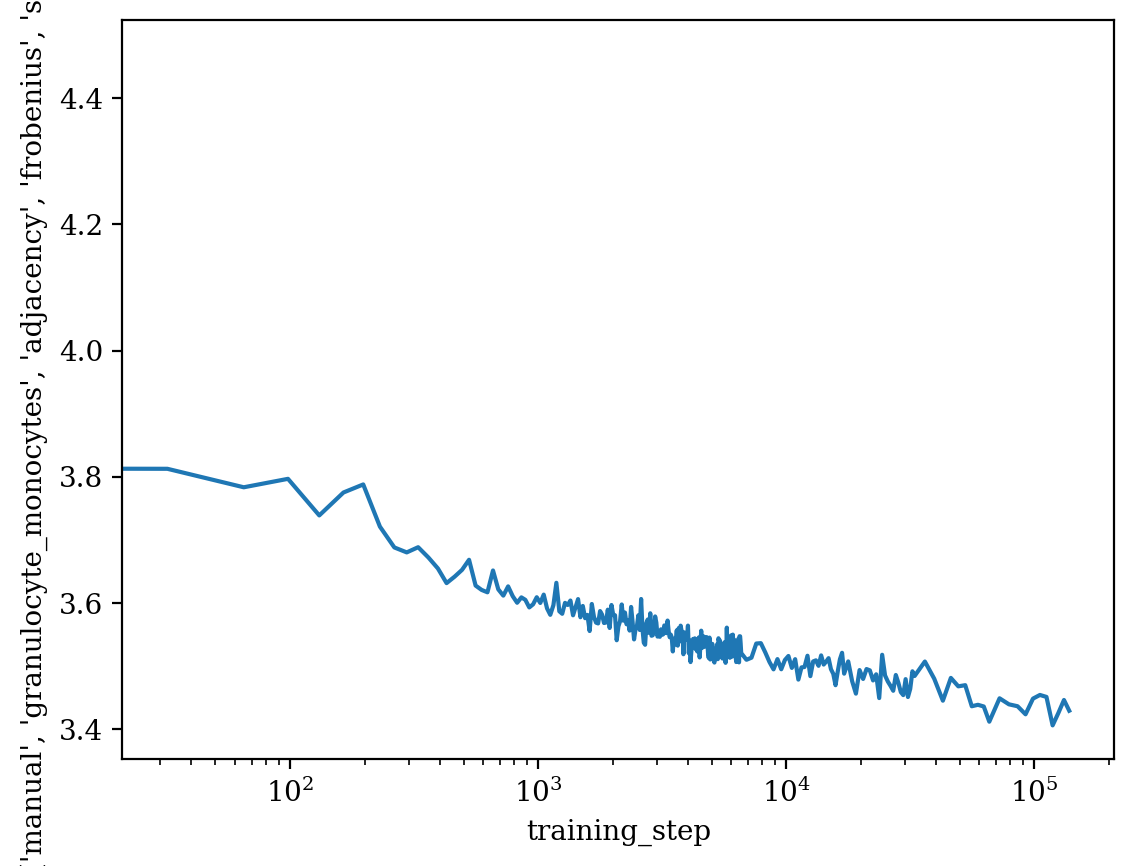

In [195]:
k = df_pivot.iloc[100]
sns.lineplot(k)
plt.xscale('log')
k.name

In [ ]:
# bu sekilde trainingstep + 1 (sifir da ciksin diye)
# for each metric, create 5 plot scanvi, 5 plot scvi in the same plot with different colors.
# for each metric of scIB metrics, create scanvi and scvi results.

In [201]:
adata_suo_complete[adata_suo_complete.obs.index]

View of AnnData object with n_obs × n_vars = 841922 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'rank_genes_groups'
    obsm: 'Unintegrated', 'X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'

In [203]:
del adata_suo_complete.X

In [206]:
adata_suo_complete

AnnData object with n_obs × n_vars = 841922 × 8192
    obs: 'sample_ID', 'organ', 'age', 'cell_type', 'sex', 'sex_inferred', 'concatenated_integration_covariates', 'integration_donor', 'integration_biological_unit', 'integration_sample_status', 'integration_library_platform_coarse', 'n_genes', '_scvi_batch', '_scvi_labels', 'LVL3', 'LVL2', 'LVL1', 'LVL0'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'rank_genes_groups'
    obsm: 'Unintegrated', 'X_pca', 'harmony', 'invae', 'scanvi', 'scvi', 'tardis_1', 'tardis_2'